# TP : Entraînement d'un Modèle YOLO pour la Détection d'Objets

Ce TP vous guide dans l'entraînement d'un modèle YOLOv11 pour la détection d'objets sur un dataset personnalisé.

Vous apprendrez à utiliser la bibliothèque Ultralytics pour charger un modèle pré-entraîné, lancer le fine-tuning, évaluer les performances sur les ensembles de validation et de test, et effectuer des prédictions sur de nouvelles images.

Le dataset utilisé contient des images de pièces de monnaie américaines au format YOLOv11, préparé lors du TP précédent.

L'objectif est d'entraîner un modèle capable de détecter et classifier ces pièces de monnaie.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.0 MB/s eta 0:00:00


### Importer les bibliothèques nécessaires

Importez les modules requis pour ce TP :
- `os` : pour la gestion des chemins de fichiers et répertoires
- `YOLO` depuis `ultralytics` : l'interface principale pour manipuler les modèles YOLO (chargement, entraînement, évaluation et prédiction)

In [3]:
import os
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Définir les chemins du dataset et de sauvegarde

Définissez les variables de chemins essentiels pour l'entraînement :
- `data_dir` : le répertoire contenant le dataset au format YOLOv11 (structure créée lors du TP précédent)
- `yaml` : le chemin complet vers le fichier de configuration YAML (`US-Coins.yaml`) qui décrit l'organisation du dataset, le nombre de classes et leurs noms
- `weights_dir` : le répertoire où seront sauvegardés les poids du modèle entraîné et les métriques d'entraînement

Ces chemins seront utilisés tout au long du processus d'entraînement et d'évaluation.

In [13]:
data_dir = "/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11"
yaml = "/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/US-Coins.yaml"
weights_dir = "/content/drive/MyDrive/computer_vision/td11/train/weights"

print("Dataset directory:", data_dir)
print("YAML file:", yaml)
print("Weights directory:", weights_dir)

Dataset directory: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11
YAML file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/US-Coins.yaml
Weights directory: /content/drive/MyDrive/computer_vision/td11/train/weights


### Entraîner le modèle YOLO

Chargez le modèle YOLOv11 nano pré-entraîné (`yolo11n.pt`), puis lancez l'entraînement (fine-tuning) en spécifiant les paramètres suivants :

- `data` : le chemin vers le fichier YAML de configuration du dataset
- `epochs` : le nombre d'époques d'entraînement (par exemple 100).
- `imgsz` : la taille d'image utilisée pour l'entraînement (ici 640)
- `project` : le répertoire où sauvegarder les résultats d'entraînement (poids, métriques, graphiques)

Des paramètres optionnels comme `batch` (taille des lots) et `num_workers` (nombre de processus pour le chargement des données) peuvent être ajustés en fonction de votre machine.

L'entraînement peut prendre plusieurs minutes selon votre matériel. YOLO affichera automatiquement la progression, les métriques (loss, précision, recall, mAP) et sauvegardera les meilleurs poids dans le sous-dossier `train/weights/` du projet.

In [16]:
model = YOLO("yolo11n.pt")

model.train(
    data="/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/US-Coins.yaml",
    epochs=100,
    imgsz=640,
    project=weights_dir,
    # batch=8, # Taille du lot
    # num_workers=2 # Nombre de travailleurs pour le chargement des données
)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/US-Coins.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ceda61a2cf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

### Charger les poids du modèle entraîné

Chargez les meilleurs poids sauvegardés lors de l'entraînement en suivant ces étapes :
- Construisez le chemin vers le fichier `best.pt` situé dans `train/weights/` du répertoire projet
- Ces poids correspondent à l'époque où le modèle a obtenu les meilleures performances sur l'ensemble de validation
- Créez une nouvelle instance de `YOLO` avec ces poids pour les utiliser dans les étapes de prédiction et d'évaluation

NB : cette étape est optionnelle si vous venez d'entrainer le modèle...

Remarque : si vous relancez plusieurs fois l'entraînement, YOLO créera automatiquement des sous-dossiers numérotés (train, train2, train3, etc.) pour éviter d'écraser les résultats précédents. Pensez à adapter le chemin vers les poids si nécessaire.

In [17]:
trained_weights = weights_dir+"/best.pt"
model = YOLO(trained_weights)

### Sélectionner des images de test

Préparez une liste d'images pour tester visuellement les prédictions du modèle :
- Utilisez `glob` pour lister tous les fichiers `.jpg` présents dans `test/images` du dataset YOLO
- Sélectionnez les 5 premières images et stockez ces chemins dans la variable `test_files`
- Affichez la liste pour vérifier les chemins sélectionnés

In [18]:
import os
import glob
test_files = glob.glob("/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images/*.jpg")
display(test_files)

['/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images/coins_46_jpeg.rf.0482c80f40cb607e0a0ad8a1696ea906.jpg',
 '/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images/coins_11_jpeg.rf.f48a16ff01c897733fdd44761f945ac6.jpg',
 '/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images/coins_42_jpeg.rf.af72de5a7e9b5fbe6e65629313decd43.jpg',
 '/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images/coins_13_jpeg.rf.b8d5ab25a5ad643a5276bcc63803349d.jpg',
 '/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images/coins_39_jpeg.rf.12a2e2b4092ca2dad8a34f8f53c7ed29.jpg']

### Effectuer des prédictions sur ces images de test

Appelez la méthode `.predict()` du modèle en lui passant la liste `test_files`. Cette méthode effectue l'inférence de détection d'objets sur chaque image et retourne un objet `results`.

In [19]:
results = model.predict(test_files)
print(results)


0: 640x640 2 Dimes, 5 Nickels, 3 Pennys, 3 Quarters, 14.9ms
1: 640x640 4 Dimes, 5 Pennys, 2 Quarters, 14.9ms
2: 640x640 3 Dimes, 14.9ms
3: 640x640 3 Dimes, 6 Nickels, 2 Quarters, 14.9ms
4: 640x640 3 Dimes, 2 Quarters, 14.9ms
Speed: 4.7ms preprocess, 14.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Dime', 1: 'Nickel', 2: 'Penny', 3: 'Quarter'}
obb: None
orig_img: array([[[201, 153,  71],
        [202, 154,  72],
        [204, 156,  74],
        ...,
        [192, 145,  71],
        [203, 156,  82],
        [206, 159,  85]],

       [[205, 157,  75],
        [195, 147,  65],
        [191, 143,  61],
        ...,
        [182, 136,  59],
        [201, 154,  80],
        [210, 164,  87]],

       [[204, 156,  74],
        [203, 155,  73],
        [202, 154,  72],
        ...,
        [171, 125,  47],
        [192, 146,  

### Visualiser les résultats des prédictions

Parcourez la liste et affichez les résultats.

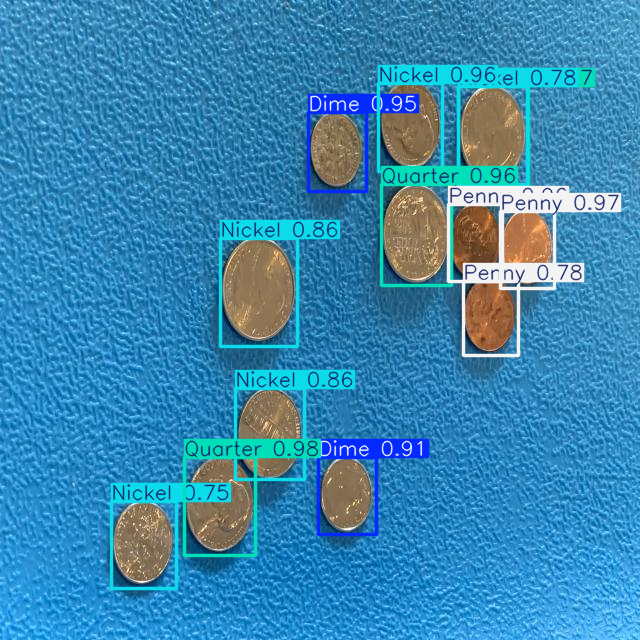

In [20]:
results[0].show()

### Évaluer le modèle sur l'ensemble de validation

Utilisez la méthode `.val()` pour évaluer quantitativement les performances du modèle entraîné sur l'ensemble de validation. Spécifiez les paramètres suivants :
- `data` : le fichier YAML de configuration du dataset
- `split='val'` : indique d'utiliser l'ensemble de validation pour l'évaluation
- `save=False` : désactive la sauvegarde des prédictions visualisées (économie d'espace disque)
- `plots=False` : désactive la génération automatique de graphiques de métriques
- `verbose=True` : affiche les résultats détaillés dans la console

La méthode retourne un objet `metrics` contenant diverses métriques de détection :
- Précision moyenne (`mp`) : proportion de détections correctes parmi toutes les détections
- Recall moyen (`mr`) : proportion d'objets réels correctement détectés
- mAP@0.5 (`map50`) : précision moyenne pour un seuil IoU de 0.5
- mAP@0.5:0.95 (`map`) : précision moyenne pour des seuils IoU de 0.5 à 0.95 (métrique la plus stricte)
- ... d'autres ...

Vous pouvez décommenter les lignes d'affichage pour consulter ces valeurs individuellement.

In [21]:
metrics = model.val(data=yaml, split='val', save=False, plots=False)
print(f"Mean Precision: {metrics.box.mp}")
print(f"Mean Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 46.7±16.6 MB/s, size: 68.3 KB)
val: Scanning /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/val/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 14.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.8it/s 0.4s
                   all         10        111        0.9      0.877      0.926      0.797
                  Dime          7         24      0.951          1      0.995      0.834
                Nickel          5         13       0.74      0.692      0.788      0.665
                 Penny          9         41          1      0.844      0.973      0.851
               Quarter          7         33      0.911       0.97       0.95      0.836
Speed: 1.7ms preprocess, 10.1ms inference, 0.0ms loss, 3.7ms postprocess per image
Mean Pr

### Évaluer le modèle sur l'ensemble de test

Répétez l'évaluation quantitative sur l'ensemble de test :
- L'ensemble de test contient des images jamais vues pendant l'entraînement
- Ces images n'ont pas été utilisées pour la sélection des meilleurs poids
- Cette évaluation finale fournit une estimation non biaisée des performances en situation réelle
- Elle permet de vérifier qu'il n'y a pas de surapprentissage

Comparez les métriques obtenues sur le test avec celles de la validation pour analyser la capacité de généralisation du modèle.

In [22]:
metrics = model.val(data=yaml, split='test', save=False, plots=False)
print(f"Mean Precision: {metrics.box.mp}")
print(f"Mean Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 47.6±11.1 MB/s, size: 74.1 KB)
val: Scanning /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/labels... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 2.6it/s 1.9s
val: New cache created: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.2it/s 0.2s
                   all          5         40      0.669      0.539      0.684      0.564
                  Dime          3          9      0.657      0.855      0.787      0.624
                Nickel          2          6      0.311      0.333      0.441      0.398
                 Penny          3         15      0.997      0.467      0.743       0.57
               Quarter          4         10      0.709        0.5      0.764    

### Nettoyer les fichiers temporaires (optionnel)

La méthode `.val()` peut créer un dossier `./runs` contenant des fichiers temporaires et des visualisations. Pour nettoyer votre espace de travail :
- Vérifiez l'existence du dossier avec `os.path.exists()`
- Supprimez-le récursivement avec `shutil.rmtree()` s'il existe
- Affichez un message de confirmation approprié

Cette étape est optionnelle et peut être utile pour maintenir un environnement de travail organisé.

In [23]:
# (optionnel) : Nettoyage du dossier généré par model.val()

import os
import shutil

if os.path.exists('./runs'):
    shutil.rmtree('./runs')
    print("Directory './runs' has been deleted")
else:
    print("Directory './runs' does not exist")

Directory './runs' has been deleted
